In [ ]:
import os
os.environ["USE_TF"] = "0"      # disable TensorFlow backend
os.environ["USE_TORCH"] = "1"   # use PyTorch backend

import transformers
import torch
import sklearn
import fairlearn
import aif360
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from torch.utils.data import Dataset
import accelerate
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make CUDA operations more deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


d:\D-Documents\University\sem7_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

train_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\jigsaw-unintended-bias-train.csv'
test_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\validation.csv'

columns_ = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
toxicity_threshold = 0.5
seed = 42
val_ratio = 0.2

set_seed(seed)


# Part 1

In [3]:

df = pd.read_csv(train_path)

filtered_df = df[columns_]

filtered_df = filtered_df.dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])

filtered_df['toxic_binarized'] = (filtered_df['toxic'] >= toxicity_threshold).astype(int)


In [4]:
filtered_df

,comment_text,toxic,black,white,muslim,jewish,other_sexual_orientation,toxic_binarized
0,"This is so cool. It's like, 'would you want yo...",0.000000,NaN,NaN,NaN,NaN,NaN,0
1,Thank you!! This would make my life a lot less...,0.000000,NaN,NaN,NaN,NaN,NaN,0
2,This is such an urgent design problem; kudos t...,0.000000,NaN,NaN,NaN,NaN,NaN,0
3,Is this something I'll be able to install on m...,0.000000,NaN,NaN,NaN,NaN,NaN,0
4,haha you guys are a bunch of losers.,0.893617,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...
1902189,He should lose his job for promoting mis-infor...,0.000000,NaN,NaN,NaN,NaN,NaN,0
1902190,"""Thinning project is meant to lower fire dange...",0.166667,NaN,NaN,NaN,NaN,NaN,0
1902191,I hope you millennials are happy that you put ...,0.400000,NaN,NaN,NaN,NaN,NaN,0
1902192,I'm thinking Kellyanne Conway (a.k.a. The Trum...,0.000000,NaN,NaN,NaN,NaN,NaN,0


In [5]:

train_df, val_df = train_test_split(
    filtered_df,
    test_size=20000,
    train_size=100000,
    random_state=seed,
    stratify=filtered_df["toxic_binarized"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [6]:
train_ids = set(train_df['comment_text'])
val_ids = set(val_df['comment_text'])

overlapping_ids = train_ids.intersection(val_ids)

if len(overlapping_ids) == 0:
    print("✅ Verification passed: No overlapping samples between train and validation sets.")
else:
    print(f"⚠️ Warning: Found {len(overlapping_ids)} overlapping samples!")

✅ Verification passed: No overlapping samples between train and validation sets.


In [7]:
# Check class balance in the full set vs train/val
full_dist = filtered_df["toxic_binarized"].value_counts(normalize=True).sort_index()
train_dist = train_df["toxic_binarized"].value_counts(normalize=True).sort_index()
val_dist = val_df["toxic_binarized"].value_counts(normalize=True).sort_index()

print("Full distribution:\n", full_dist)
print("\nTrain distribution:\n", train_dist)
print("\nVal distribution:\n", val_dist)

# Optional: show raw counts too
print("\nCounts:")
print("Full:\n", filtered_df["toxic_binarized"].value_counts().sort_index())
print("Train:\n", train_df["toxic_binarized"].value_counts().sort_index())
print("Val:\n", val_df["toxic_binarized"].value_counts().sort_index())

Full distribution:
 toxic_binarized
0    0.920007
1    0.079993
Name: proportion, dtype: float64

Train distribution:
 toxic_binarized
0    0.92001
1    0.07999
Name: proportion, dtype: float64

Val distribution:
 toxic_binarized
0    0.92
1    0.08
Name: proportion, dtype: float64

Counts:
Full:
 toxic_binarized
0    1726363
1     150105
Name: count, dtype: int64
Train:
 toxic_binarized
0    92001
1     7999
Name: count, dtype: int64
Val:
 toxic_binarized
0    18400
1     1600
Name: count, dtype: int64


In [8]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Tokenize all comments in the dataframe
encoded = tokenizer(
    filtered_df["comment_text"].astype(str).tolist(),
    max_length=128,
    truncation=True
)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7692.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
class ToxicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["comment_text"].fillna("").astype(str).tolist()
        self.labels = dataframe["toxic_binarized"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    

train_dataset = ToxicDataset(train_df, tokenizer, max_length=128)
val_dataset = ToxicDataset(val_df, tokenizer, max_length=128)

In [10]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions[:, 1]  # For binary, take positive class logits
    preds = torch.sigmoid(torch.tensor(predictions)).numpy()  # Convert to probabilities
    preds_binary = (preds > 0.5).astype(int)
    
    accuracy = accuracy_score(labels, preds_binary)
    f1_macro = f1_score(labels, preds_binary, average='macro')
    auc_roc = roc_auc_score(labels, preds)
    conf_matrix = confusion_matrix(labels, preds_binary)
    
    print("Confusion Matrix:")
    print(conf_matrix)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'auc_roc': auc_roc,
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./distilbert-toxic",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    seed=seed,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.195866,0.136557,0.950650,0.806055,0.953443
2,0.116977,0.161223,0.950350,0.818803,0.950661
3,0.079334,0.218443,0.946600,0.812271,0.946064


Confusion Matrix:
[[18141   259]
 [  728   872]]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.27it/s]


Confusion Matrix:
[[18024   376]
 [  617   983]]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.92it/s]


Confusion Matrix:
[[17925   475]
 [  593  1007]]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.81it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18750, training_loss=0.11875618384679158, metrics={'train_runtime': 1180.4576, 'train_samples_per_second': 254.139, 'train_steps_per_second': 15.884, 'total_flos': 9935054899200000.0, 'train_loss': 0.11875618384679158, 'epoch': 3.0})

Confusion Matrix:
[[18143   257]
 [  729   871]]


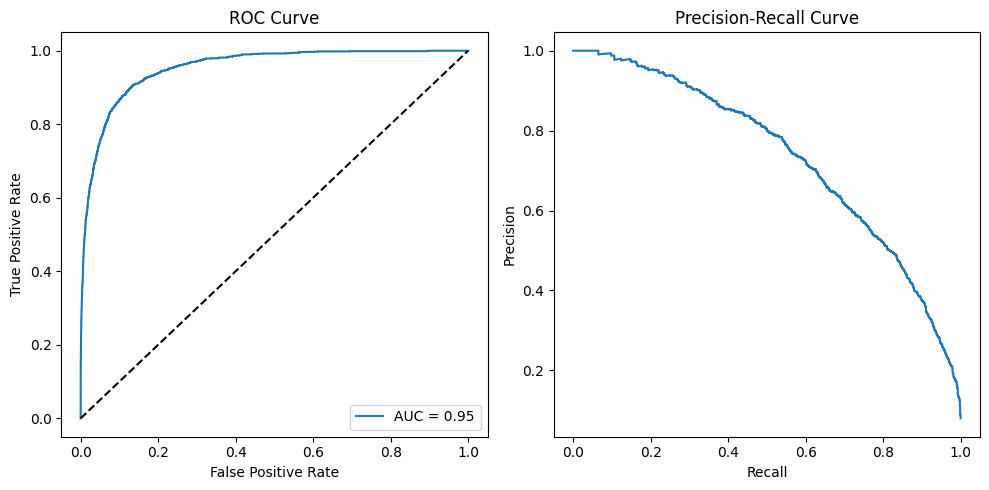

In [12]:
# Get predictions on validation set
predictions = trainer.predict(val_dataset)
preds = torch.sigmoid(torch.tensor(predictions.predictions[:, 1])).numpy()
labels = predictions.label_ids

# ROC Curve
fpr, tpr, _ = roc_curve(labels, preds)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(labels, preds):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(labels, preds)
plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

In [13]:
# Compute F1 scores at different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
f1_scores = {}

for thresh in thresholds:
    preds_binary = (preds > thresh).astype(int)
    f1 = f1_score(labels, preds_binary, average='macro')
    f1_scores[thresh] = f1
    print(f"Threshold {thresh}: F1 Macro = {f1:.4f}")

# Choose the best threshold (highest F1)
best_thresh = max(f1_scores, key=f1_scores.get)
print(f"\nBest threshold: {best_thresh} with F1 = {f1_scores[best_thresh]:.4f}")

Threshold 0.3: F1 Macro = 0.8087
Threshold 0.4: F1 Macro = 0.8156
Threshold 0.5: F1 Macro = 0.8061
Threshold 0.6: F1 Macro = 0.7864
Threshold 0.7: F1 Macro = 0.7570

Best threshold: 0.4 with F1 = 0.8156


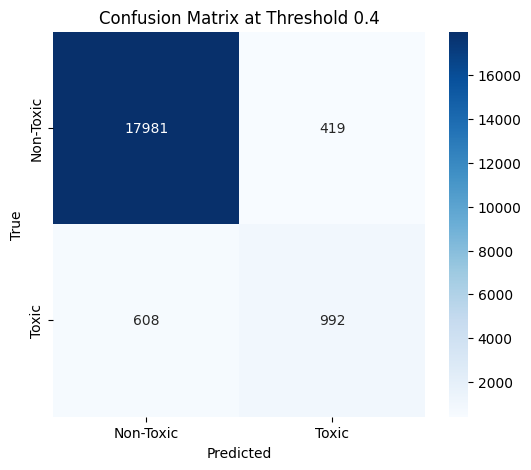

In [ ]:

# Plot confusion matrix at the best threshold
preds_binary_best = (preds > best_thresh).astype(int)
cm = confusion_matrix(labels, preds_binary_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix at Threshold {best_thresh}')
plt.show()

In [15]:
print(f"Accuracy: {accuracy_score(labels, preds_binary_best):.4f}")
print(f"F1 Macro: {f1_score(labels, preds_binary_best, average='macro'):.4f}")
print(f"AUC-ROC: {roc_auc_score(labels, preds):.4f}")

Accuracy: 0.9486
F1 Macro: 0.8156
AUC-ROC: 0.9534


In [ ]:
# Save the trained model
trainer.save_model("./distilbert-toxic/distilbert-toxic-final")
tokenizer.save_pretrained("./distilbert-toxic/distilbert-toxic-final")
print("Model and tokenizer saved to ./distilbert-toxic/distilbert-toxic-final")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.07it/s]

Model and tokenizer saved to ./distilbert-toxic-final


# Threshold Implications and Platform Priorities (Threshold: 0.4)
By selecting a threshold of 0.4 (which yielded the highest F1 Macro score of 0.8156), the implied priority of the platform is to lean slightly toward a safer, more moderated community while maintaining a strong balance against false positives.

### My Position & Justification:
I justify choosing the 0.4 threshold because it optimizes the harmonic mean of precision and recall (F1 score). The fact that the optimal threshold is slightly lower than the standard 0.5 tells us an important detail about this dataset and the platform's resulting stance:

### Catching More Toxicity:
By lowering the threshold to 0.4, the platform is willing to be slightly more aggressive in flagging toxic content. It implies that missing genuine toxicity (false negatives) is marginally more damaging to the platform's health and user base than falsely flagging a few innocent comments (false positives), especially given how severe toxic comments can impact marginalized communities.

### Avoiding Overreach (Why not 0.3?):
While 0.4 leans towards safety, it does not go to the extremes (like 0.3 or lower, which would cause an unacceptable influx of false positives). It strikes the ideal mathematical compromise, ensuring the platform remains safe without devolving into heavy-handed censorship that frustrates innocent users.

### Conclusion:
There is no perfectly "correct" threshold, but 0.4 represents a pragmatic, data-driven choice. It acknowledges that user safety is a high priority (hence the sub-0.5 threshold) without sacrificing the freedom of expression and usability of the platform.

Recreating validation dataset to avoid re-running upper training cells...
Loading model and tokenizer from ./distilbert-toxic/distilbert-toxic-final for evaluation...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13002.88it/s]

Running predictions on the loaded model...


Generating plots...


C:\Users\pc\AppData\Local\Temp\ipykernel_16360\1619132296.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(list(subgroup_f1_scores.keys()), rotation=45, ha='right')


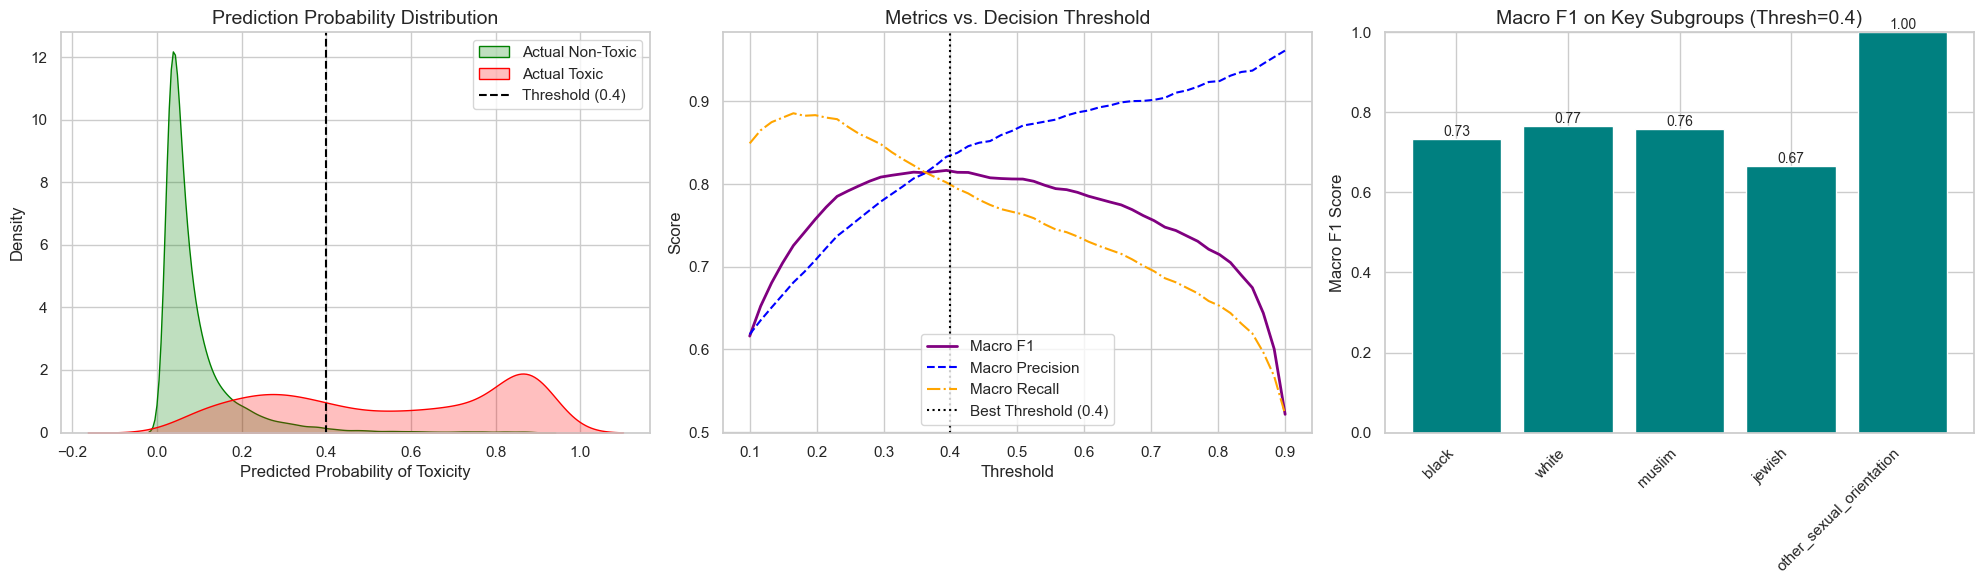

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer

sns.set_theme(style="whitegrid")

print("Recreating validation dataset to avoid re-running upper training cells...")

# 1. Load Data
train_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\jigsaw-unintended-bias-train.csv'
columns_ = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
df = pd.read_csv(train_path, usecols=columns_).dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])
df['toxic_binarized'] = (df['toxic'] >= 0.5).astype(int)

# Exact same split as top of notebook 
_, val_df = train_test_split(df, test_size=20000, train_size=100000, random_state=seed, stratify=df["toxic_binarized"])
val_df = val_df.reset_index(drop=True)

# 2. Define Dataset Class locally
class ToxicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["comment_text"].fillna("").astype(str).tolist()
        self.labels = dataframe["toxic_binarized"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length, truncation=True, padding="max_length", return_tensors="pt")
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# 3. Load Model and Tokenizer
model_dir = "./distilbert-toxic/distilbert-toxic-final"
print(f"Loading model and tokenizer from {model_dir} for evaluation...")
loaded_tokenizer = AutoTokenizer.from_pretrained(model_dir)
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_dir)

val_dataset = ToxicDataset(val_df, loaded_tokenizer, max_length=128)

# 4. Inference
print("Running predictions on the loaded model...")
loaded_trainer = Trainer(model=loaded_model)
pred_output = loaded_trainer.predict(val_dataset)

# Extract probabilities and true labels
y_prob_loaded = torch.sigmoid(torch.tensor(pred_output.predictions[:, 1])).numpy()
y_true_loaded = pred_output.label_ids
best_thresh = 0.4  # Optimal threshold we identified 

# 5. --- Create Figure for Extended Visualizations ---
print("Generating plots...")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Prediction Probability Distribution grouped by True Label
sns.kdeplot(y_prob_loaded[y_true_loaded == 0], fill=True, label='Actual Non-Toxic', color='green', ax=axes[0])
sns.kdeplot(y_prob_loaded[y_true_loaded == 1], fill=True, label='Actual Toxic', color='red', ax=axes[0])
axes[0].axvline(best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh})')
axes[0].set_title('Prediction Probability Distribution', fontsize=14)
axes[0].set_xlabel('Predicted Probability of Toxicity')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Metrics across different Thresholds
eval_thresholds = np.linspace(0.1, 0.9, 50)
f1_list, prec_list, rec_list = [], [], []

for t in eval_thresholds:
    preds_t = (y_prob_loaded > t).astype(int)
    f1_list.append(f1_score(y_true_loaded, preds_t, average='macro'))
    prec_list.append(precision_score(y_true_loaded, preds_t, average='macro', zero_division=0))
    rec_list.append(recall_score(y_true_loaded, preds_t, average='macro'))

axes[1].plot(eval_thresholds, f1_list, label='Macro F1', color='purple', linewidth=2)
axes[1].plot(eval_thresholds, prec_list, label='Macro Precision', color='blue', linestyle='--')
axes[1].plot(eval_thresholds, rec_list, label='Macro Recall', color='orange', linestyle='-.')
axes[1].axvline(best_thresh, color='black', linestyle=':', label=f'Best Threshold ({best_thresh})')
axes[1].set_title('Metrics vs. Decision Threshold', fontsize=14)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

# Plot 3: Subgroup Analysis (Fairness preview)
subgroups = ['black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
final_preds = (y_prob_loaded > best_thresh).astype(int)

eval_df = val_df.copy()
eval_df['pred_toxic'] = final_preds
subgroup_f1_scores = {}

for sg in subgroups:
    sg_mask = eval_df[sg] >= 0.5
    if sg_mask.sum() > 0:
        sg_y_true = eval_df.loc[sg_mask, 'toxic_binarized']
        sg_y_pred = eval_df.loc[sg_mask, 'pred_toxic']
        subgroup_f1_scores[sg] = f1_score(sg_y_true, sg_y_pred, average='macro', zero_division=0)

if subgroup_f1_scores:
    bars = axes[2].bar(list(subgroup_f1_scores.keys()), list(subgroup_f1_scores.values()), color='teal')
    axes[2].set_title(f'Macro F1 on Key Subgroups (Thresh={best_thresh})', fontsize=14)
    axes[2].set_ylabel('Macro F1 Score')
    axes[2].set_xticklabels(list(subgroup_f1_scores.keys()), rotation=45, ha='right')
    axes[2].set_ylim(0, 1.0)
    for bar in bars:
        axes[2].annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
else:
    axes[2].set_title('No Subgroup Data in Eval Set', fontsize=14)

plt.tight_layout()
plt.show()